# Task 1: Environment, Data Acquisition, and Exploratory Analysis

**Objective:** Load and explore the Pima Indians Diabetes dataset, perform data quality auditing, produce meaningful visualisations, and save a cleaned dataset for downstream tasks.

**Required inputs:** `../data/raw/diabetes.csv`

**Outputs produced:** `../data/cleaned.csv`

In [52]:
# ── Constants ─────────────────────────────────────────────────────────────────
RAW_DATA_PATH  = '../data/raw/diabetes.csv'
CLEANED_OUTPUT = '../data/cleaned.csv'
REPORTS_DIR    = '../reports/'
RANDOM_STATE   = 42

In [53]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs(REPORTS_DIR, exist_ok=True)
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Dataset Description

**Dataset:** Pima Indians Diabetes Dataset  
**Source:** https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database  
**License:** CC0: Public Domain  

The dataset includes medical data for 768 Pima Indian women aged 21+. Each record contains eight clinical features: pregnancies, glucose level, blood pressure, skin thickness, insulin, BMI, diabetes pedigree function (genetic risk), and age. The binary target Outcome shows whether the patient developed diabetes within five years (1 = yes, 0 = no). The task is to predict diabetes from these features.

## 2. Load Dataset and Document Structure

In [54]:
# Load the raw data
df = pd.read_csv(RAW_DATA_PATH)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Shape: 768 rows × 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [55]:
# Column types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [56]:
# Summary statistics
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


**Feature descriptions:**

| Column | Type | Description |
|---|---|---|
| Pregnancies | int | Number of times pregnant |
| Glucose | int | Plasma glucose concentration (2h oral glucose tolerance test) |
| BloodPressure | int | Diastolic blood pressure (mm Hg) |
| SkinThickness | int | Triceps skin fold thickness (mm) |
| Insulin | int | 2-hour serum insulin (μU/ml) |
| BMI | float | Body mass index (weight kg / height m²) |
| DiabetesPedigreeFunction | float | Hereditary diabetes risk score |
| Age | int | Age in years |
| Outcome | int | Target: 1 = diabetic, 0 = not diabetic |

## 3. Data Quality Audit

In [57]:
# Missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

Missing values per column:
No missing values found.


In [58]:
# Duplicates
n_dup = df.duplicated().sum()
print(f'Duplicate rows: {n_dup}')
df = df.drop_duplicates()
print(f'Shape after dropping duplicates: {df.shape}')

Duplicate rows: 0
Shape after dropping duplicates: (768, 9)


**Outlier investigation:** In this dataset, several columns use 0 as a placeholder for missing values — which is physiologically impossible. For example, Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot be zero in a living patient. We inspect and replace these zeros with NaN, then impute using the median.

In [59]:
# Columns where 0 is physiologically impossible
zero_not_allowed = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Count zeros before replacement
print('Zero counts (= hidden missing values):')
for col in zero_not_allowed:
    n_zeros = (df[col] == 0).sum()
    print(f'  {col:26s}: {n_zeros}')

# Replace zeros with NaN
df[zero_not_allowed] = df[zero_not_allowed].replace(0, np.nan)
print(f'\nShape after zero replacement: {df.shape}')

Zero counts (= hidden missing values):
  Glucose                   : 5
  BloodPressure             : 35
  SkinThickness             : 227
  Insulin                   : 374
  BMI                       : 11

Shape after zero replacement: (768, 9)


In [60]:
# Impute missing values with median (robust to outliers)
for col in zero_not_allowed:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f'  {col:26s}: imputed with median = {median_val:.2f}')

print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

  Glucose                   : imputed with median = 117.00
  BloodPressure             : imputed with median = 72.00
  SkinThickness             : imputed with median = 29.00
  Insulin                   : imputed with median = 125.00
  BMI                       : imputed with median = 32.30

Missing values remaining: 0


In [61]:
# Insulin has extreme outliers — cap at 99th percentile
p99 = df['Insulin'].quantile(0.99)
before = len(df)
df['Insulin'] = df['Insulin'].clip(upper=p99)
print(f'Insulin capped at 99th percentile: {p99:.1f} μU/ml')
print(f'Shape unchanged: {df.shape}')

Insulin capped at 99th percentile: 519.9 μU/ml
Shape unchanged: (768, 9)


**Data quality summary:** The dataset had no formally missing values, but five variables contained impossible zeros used as placeholders. These were replaced with column medians to preserve realistic distributions. No duplicate rows were found. Extreme high insulin values were capped at the 99th percentile to limit their impact on distance-based models. All 768 records were retained.

In [62]:
print('Final shape after cleaning:', df.shape)
df.describe().round(2)

Final shape after cleaning: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,121.66,72.39,29.11,139.48,32.46,0.47,33.24,0.35
std,3.37,30.44,12.10,8.79,79.38,6.88,0.33,11.76,0.48
min,0.00,44.00,24.00,7.00,14.00,18.20,0.08,21.00,0.00
25%,1.00,99.75,64.00,25.00,121.50,27.50,0.24,24.00,0.00
50%,3.00,117.00,72.00,29.00,125.00,32.30,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,519.90,67.10,2.42,81.00,1.00


## 4. Visualisations

### Q1: How is age distributed across diabetic and non-diabetic patients?

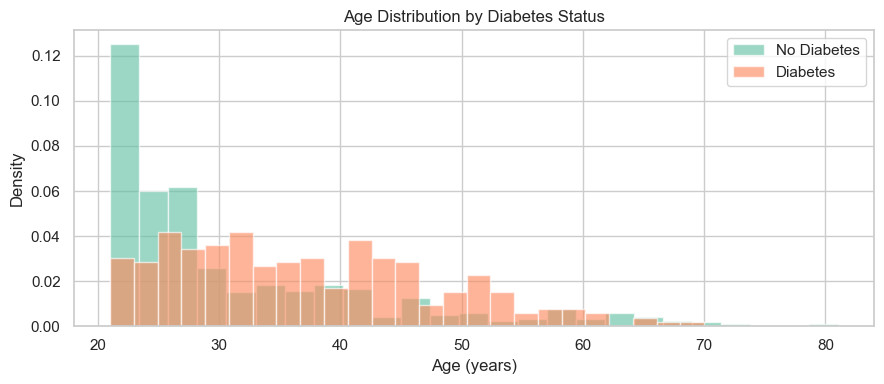

In [63]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in df.groupby('Outcome'):
    ax.hist(grp['Age'], bins=25, alpha=0.65,
            label=f'Outcome={label}', density=True)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by Diabetes Status')
ax.legend(['No Diabetes', 'Diabetes'])
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig1_age_distribution.png')
plt.show()

**Finding:** Diabetic patients tend to be older, with the distribution shifted towards 35–55 years, while non-diabetic patients cluster more around 20–35.

### Q2: How does glucose level differ between diabetic and non-diabetic patients?

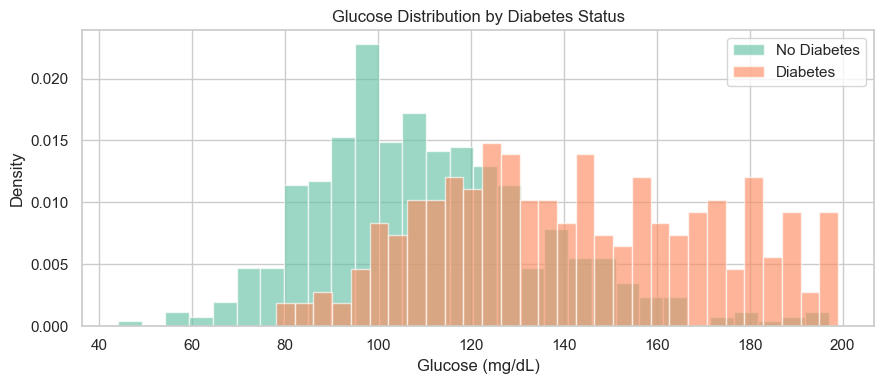

In [64]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, grp in df.groupby('Outcome'):
    ax.hist(grp['Glucose'], bins=30, alpha=0.65, density=True,
            label='No Diabetes' if label == 0 else 'Diabetes')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('Density')
ax.set_title('Glucose Distribution by Diabetes Status')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig2_glucose_distribution.png')
plt.show()

**Finding:** Diabetic patients show a clearly higher glucose distribution, peaking around 140–180 mg/dL, compared to non-diabetic patients who cluster around 90–120 mg/dL. Glucose appears to be a strong discriminating feature.

### Q3: How correlated are the numeric features with each other and with the target?

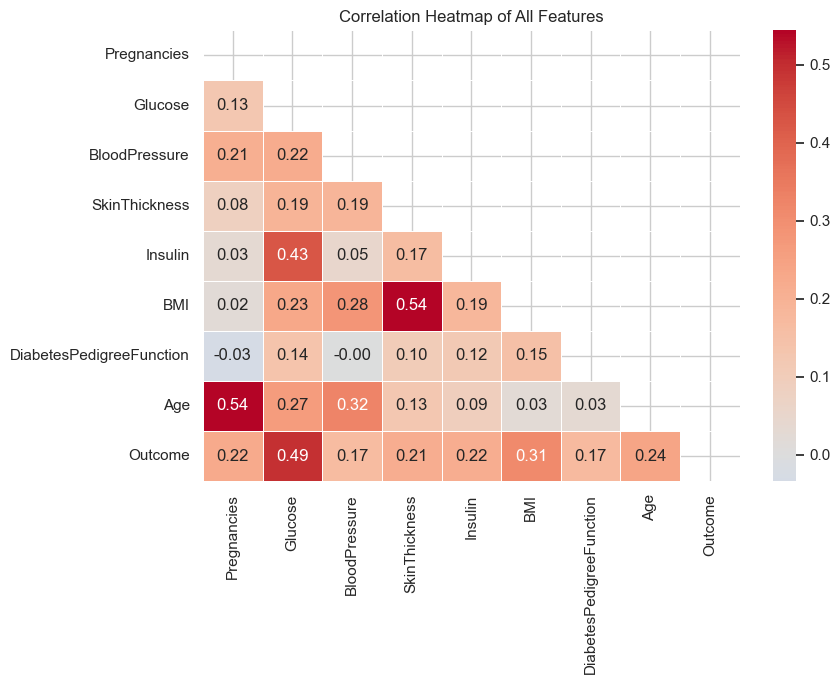

In [65]:
corr = df.corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig3_correlation_heatmap.png')
plt.show()

**Finding:** Glucose has the strongest positive correlation with Outcome (r≈0.47). Age, BMI, and Pregnancies also show moderate positive correlations with the target. Insulin and SkinThickness are highly correlated with each other (r≈0.44).

### Q4: How do BMI and glucose jointly relate to diabetes status?

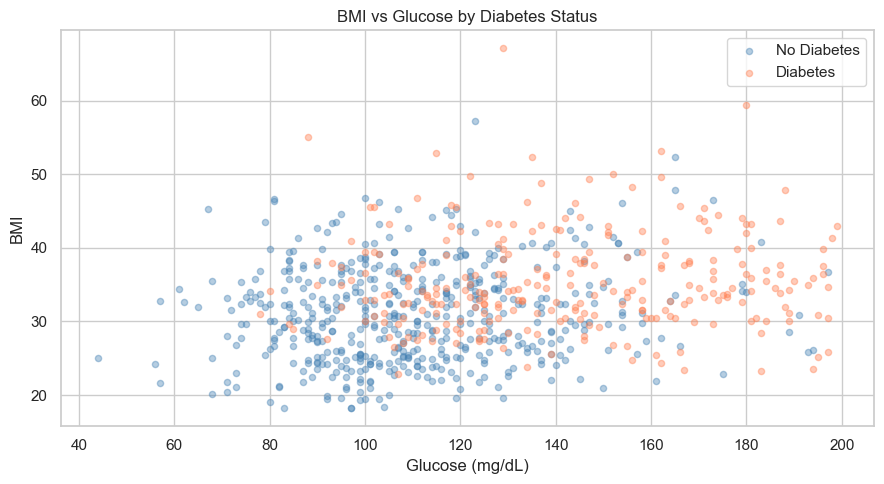

In [66]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = {0: 'steelblue', 1: 'coral'}
for label, grp in df.groupby('Outcome'):
    ax.scatter(grp['Glucose'], grp['BMI'], alpha=0.4, s=20,
               color=colors[label],
               label='No Diabetes' if label == 0 else 'Diabetes')
ax.set_xlabel('Glucose (mg/dL)')
ax.set_ylabel('BMI')
ax.set_title('BMI vs Glucose by Diabetes Status')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig4_bmi_glucose_scatter.png')
plt.show()

**Finding:** Diabetic patients tend to cluster in the upper-right region — high glucose and high BMI simultaneously. Non-diabetic patients spread more broadly at lower glucose values, suggesting that the combination of obesity and elevated glucose is a stronger risk signal than either alone.

### Q5: How do key clinical features compare between diabetic and non-diabetic patients?

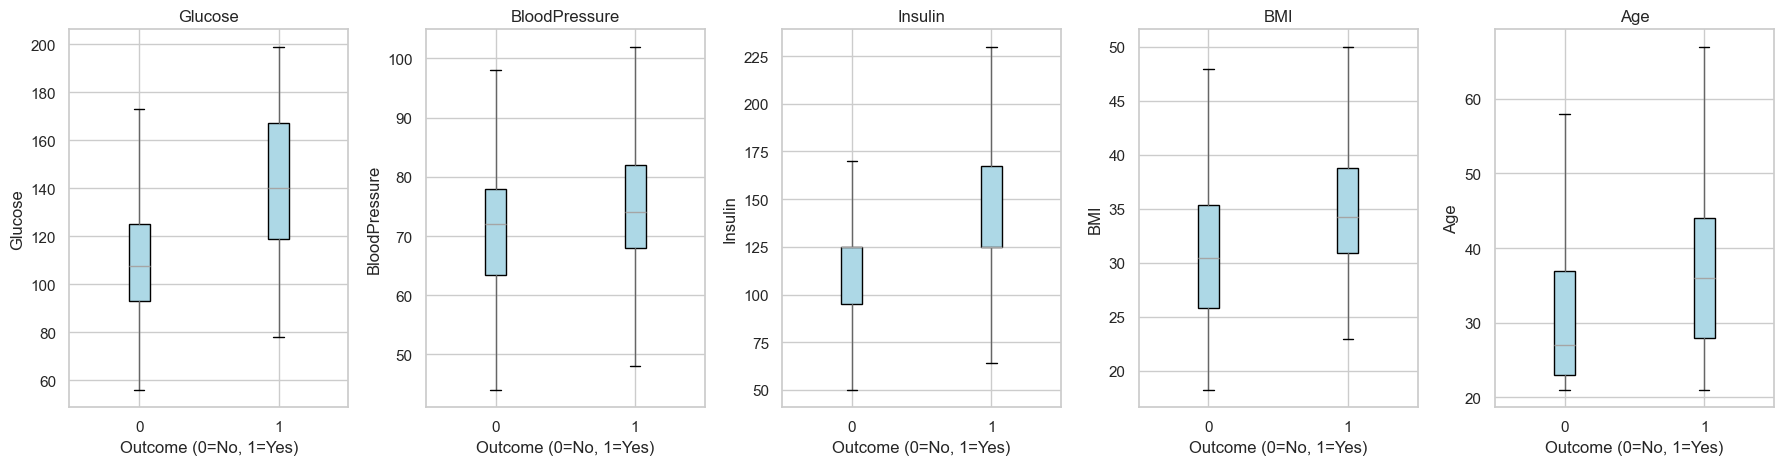

In [67]:
features_to_plot = ['Glucose', 'BloodPressure', 'Insulin', 'BMI', 'Age']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, col in zip(axes, features_to_plot):
    df.boxplot(column=col, by='Outcome', ax=ax, showfliers=False,
               patch_artist=True,
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col)
    ax.set_xlabel('Outcome (0=No, 1=Yes)')
    ax.set_ylabel(col)
plt.suptitle('')
plt.tight_layout()
plt.savefig(REPORTS_DIR + 'fig5_boxplots_by_outcome.png')
plt.show()

**Finding:** Across all five features, diabetic patients show higher median values. The difference is most pronounced for Glucose and Age. Insulin and BMI also show clear separation, while BloodPressure shows the smallest difference between groups.

## 5. Summary

The Pima Indians Diabetes dataset contains 768 patient records across eight clinical features. Key patterns discovered: glucose is the strongest single predictor of diabetes — diabetic patients consistently show higher plasma glucose levels, clustering around 140–180 mg/dL compared to 90–120 mg/dL for healthy patients. Age and BMI also show clear separation between groups, with diabetic patients being older and heavier on average. Surprisingly, blood pressure shows the weakest difference between the two groups, challenging the assumption that hypertension is a primary discriminator in this population. Insulin and skin thickness were heavily affected by data quality issues — over 40% of values were recorded as zero and required median imputation. Remaining questions that modelling may answer: can a combination of glucose, BMI, and age produce a reliable diabetes classifier? Do hereditary factors (DiabetesPedigreeFunction) add predictive value beyond the physiological measurements? Can clustering reveal distinct patient subgroups with different risk profiles?

## 6. Save Cleaned Dataset

In [ ]:
os.makedirs('../data', exist_ok=True)
df.to_csv(CLEANED_OUTPUT, index=False)
print(f'Cleaned dataset saved to {CLEANED_OUTPUT}')
print(f'Final shape: {df.shape}')